# OSM Points Features - Berlin

Downloads OSM point features (traffic signals, transport stops, amenity POIs) for city of Berlin,
counts them per street segment within a 50 m buffer, and exports `data/osm_points_features.csv`.
Roads loaded from `../layers/BER_noise_streets.gpkg` (70,890 segments, EPSG:25833).

In [24]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

## Import roads

In [25]:
osm_roads = gpd.read_file("../layers/BER_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25833
(70890, 12)
['segment_id', 'highway', 'name', 'length', 'GES_DEN_mean', 'GES_N_mean', 'noise_day', 'noise_evening', 'noise_night', 'n_points', 'distance', 'geometry']
Number of street segments: 70890


## Traffic Signals - OSM

In [26]:
signals = ox.features_from_place("Berlin, Germany", tags={"highway": "traffic_signals"})
signals = signals[signals.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(signals.crs)
print(signals.columns.tolist())

EPSG:25833
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'crossing:island', 'temporary', 'button_operated', 'crossing', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'TMC:cid_58:tabcd_1:Class', 'TMC:cid_58:tabcd_1:Direction', 'TMC:cid_58:tabcd_1:LCLversion', 'TMC:cid_58:tabcd_1:LocationCode', 'TMC:cid_58:tabcd_1:NextLocationCode', 'TMC:cid_58:tabcd_1:PrevLocationCode', 'crossing_ref', 'check_date:cycleway', 'ele', 'mapillary', 'removed:highway', 'image', 'survey:date', 'wheelchair', 'kerb', 'layer', 'crossing:bicycle', 'traffic_signals:countdown', 'red_turn:right:bicycle', 'check_date:tactile_paving', 'source', 'bicycle', 'description', 'traffic_sign', 'crossing:markings', 'foot', 'stop_line', 'stop_line:angle', 'check_date:traffic_signals:sound', 'supervised', 'note', 'red_turn:right', 'button_operated:bicycle', 'direction', 'destination', 'access', 'barrier', 'motorcar', 'motorcycle', 'lit', 'traffic_signals:colours', 'old_name', 't

In [27]:
print(f"Total signals: {len(signals)}")
if 'traffic_signals' in signals.columns:
    print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
    print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
    print("\nValue counts:")
    print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 8987
Non-null traffic_signals: 3953
Null traffic_signals: 5034

Value counts:
traffic_signals
NaN                    5034
signal                 3698
cyclist_crossing         91
traffic_lights           63
pedestrian_crossing      53
emergency                29
tram_priority             6
junction                  4
on_demand                 4
request_button            2
bicycle                   1
bus_priority              1
continuous_green          1
Name: count, dtype: int64


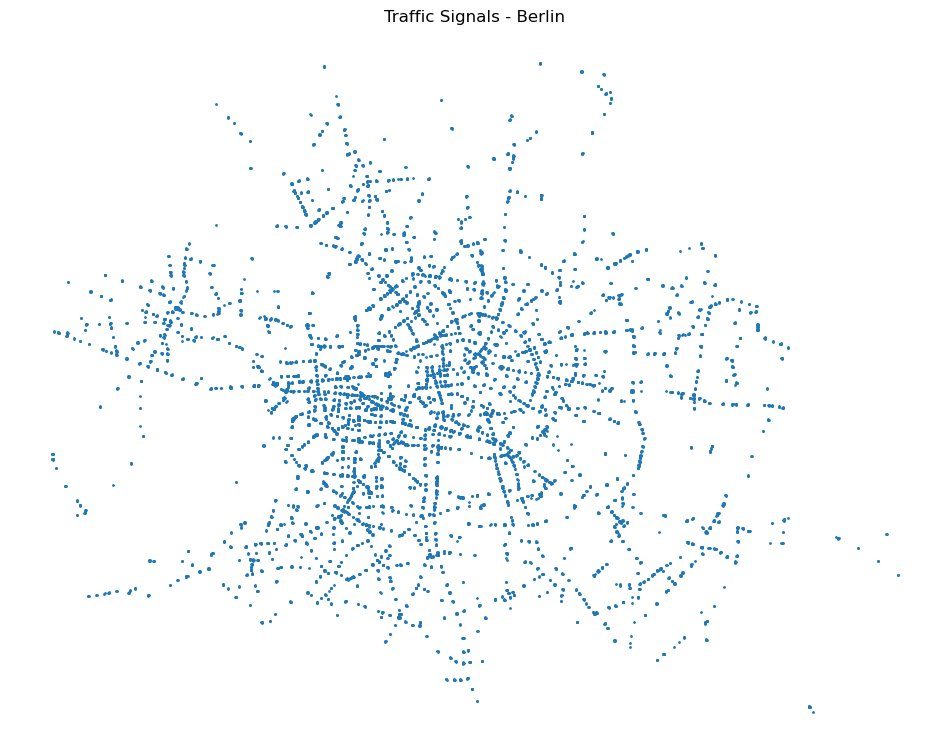

In [28]:
ax = signals.plot(markersize=1, figsize=(12, 12))
ax.set_title('Traffic Signals - Berlin')
ax.set_axis_off()

## Transport - OSM

In [29]:
transport = ox.features_from_place(
    "Berlin, Germany",
    tags={"railway": ["station", "tram_stop", "subway_entrance"],
          "highway": "bus_stop"})
transport = transport[transport.geometry.type == 'Point'].to_crs(osm_roads.crs)
if 'railway' in transport.columns:
    transport['transport_type'] = transport['railway'].fillna(
        transport['highway'] if 'highway' in transport.columns else None
    )
elif 'highway' in transport.columns:
    transport['transport_type'] = transport['highway']
else:
    transport['transport_type'] = 'unknown'
print(transport.crs)
print(transport.columns.tolist())

EPSG:25833
['geometry', 'bench', 'bin', 'bus', 'check_date:shelter', 'highway', 'lit', 'name', 'public_transport', 'ref:BVG', 'shelter', 'tactile_paving', 'website', 'wheelchair', 'contact:website', 'light_rail', 'network', 'network:short', 'network:wikidata', 'official_name', 'operator', 'railway', 'railway:ref', 'railway:station_category', 'station', 'train', 'uic_ref', 'wikidata', 'wikipedia', 'contact:phone', 'departures_board', 'departures_board:speech_output', 'description', 'ref', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'ref:ibnr', 'ref:station', 'uic_name', 'route_ref', 'gtfs:stop_id', 'note:en', 'operator:short', 'operator:wikidata', 'direction', 'tram', 'loc_name', 'note', 'start_date', 'toilets:wheelchair', 'subway', 'image', 'source', 'line', 'atm', 'atm:operator', 'check_date:wheelchair', 'internet_access', 'internet_access:fee', 'level', 'surveillance', 'old_name', 'railway:ref:parent', 'source:address', 'passenger_information_display', 'phone', '

In [30]:
print(f"Total transport points: {len(transport)}")
print(f"Non-null transport points: {transport['transport_type'].notna().sum()}")
print(f"Null transport points: {transport['transport_type'].isna().sum()}")
print("\nValue counts:")
print(transport['transport_type'].value_counts(dropna=False))

Total transport points: 8144
Non-null transport points: 8144
Null transport points: 0

Value counts:
transport_type
bus_stop           6260
tram_stop           892
subway_entrance     708
station             283
tram_crossing         1
Name: count, dtype: int64


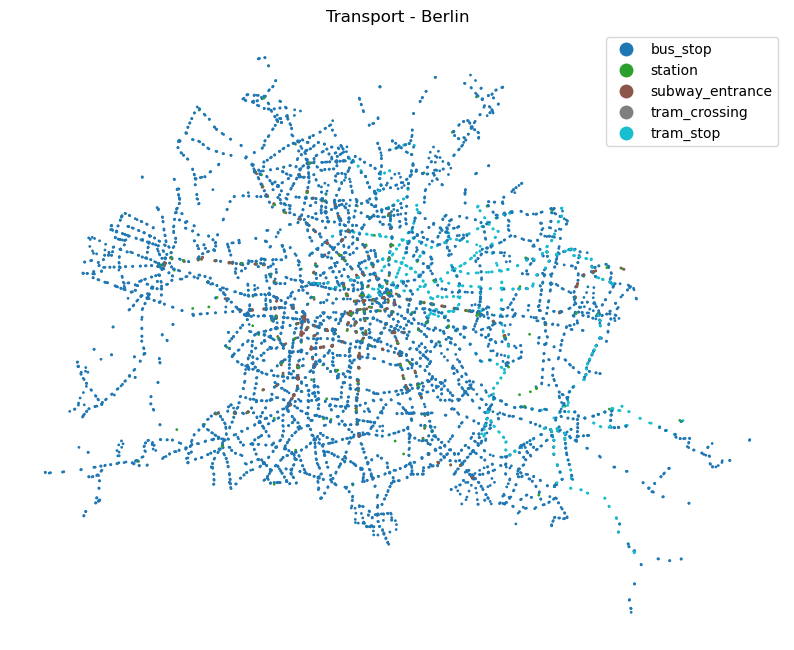

In [31]:
ax = transport.plot(column='transport_type', legend=True, markersize=1, figsize=(10, 10))
ax.set_title('Transport - Berlin')
ax.set_axis_off()

## Points Of Interest (POIs) - OSM

In [32]:
pois = ox.features_from_place(
    "Berlin, Germany",
    tags={"amenity": True}
)
pois = pois[pois.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(pois.crs)
print(pois.columns.tolist())

EPSG:25833
['geometry', 'amenity', 'brand', 'brand:wikidata', 'brand:wikipedia', 'compressed_air', 'fuel:HGV_diesel', 'fuel:diesel', 'fuel:e10', 'fuel:octane_102', 'fuel:octane_95', 'man_made', 'name', 'opening_hours', 'surveillance', 'wheelchair', 'addr:city', 'addr:country', 'addr:postcode', 'addr:street', 'addr:suburb', 'cuisine', 'email', 'outdoor_seating', 'phone', 'toilets:wheelchair', 'website', 'website:menu', 'addr:housenumber', 'contact:website', 'opening_hours:kitchen', 'wheelchair:description', 'access', 'maxheight', 'parking', 'check_date', 'fuel:ethanol', 'level', 'operator', 'payment:cash', 'payment:mastercard', 'payment:visa', 'check_date:recycling', 'recycling:glass_bottles', 'recycling_type', 'check_date:opening_hours', 'fuel:adblue', 'fuel:biodiesel', 'fuel:octane_98', 'shop', 'car_wash', 'contact:fax', 'contact:phone', 'payment:american_express', 'payment:debit_cards', 'payment:diners_club', 'payment:dkv', 'payment:maestro', 'payment:uta', 'payment:v_pay', 'payment:

### Filter and classify POIs

In [33]:
filtered_categories = ['restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court',
                        'music_venue', 'cinema', 'theatre', 'shopping_mall', 'shop', 'supermarket', 'marketplace']
pois_filtered = pois[pois['amenity'].isin(filtered_categories)]

traffic_categories = ['taxi']
pois_traffic = pois[pois['amenity'].isin(traffic_categories)]

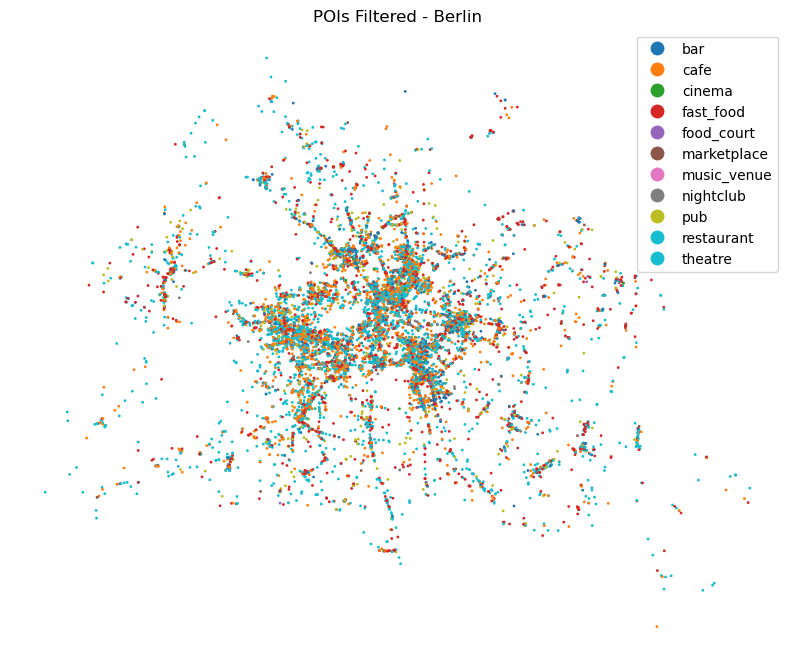

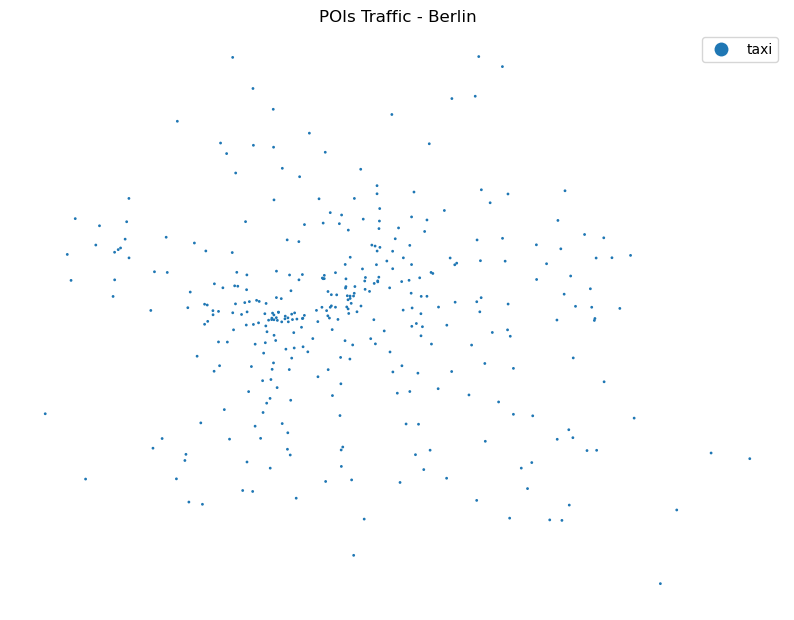

In [34]:
ax = pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Filtered - Berlin')
ax.set_axis_off()

ax = pois_traffic.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Traffic - Berlin')
ax.set_axis_off()

## Signals in 50 m buffer

In [35]:
buffered_50 = osm_roads.copy()
buffered_50['geometry'] = buffered_50.geometry.buffer(50)

### Count signals per buffer

In [36]:
signals_join = gpd.sjoin(signals, buffered_50, how="left", predicate="within")
signals_count = signals_join.groupby('index_right').size().rename('signal_count')

In [37]:
osm_roads_sig = osm_roads.join(signals_count)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].fillna(0) / osm_roads_sig['length']
q90 = osm_roads_sig['signal_count'].quantile(0.90)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].clip(upper=q90)
osm_roads_sig['signal_count'].describe()

count    70890.000000
mean         0.008638
std          0.016932
min          0.000000
25%          0.000000
50%          0.000000
75%          0.004107
max          0.050295
Name: signal_count, dtype: float64

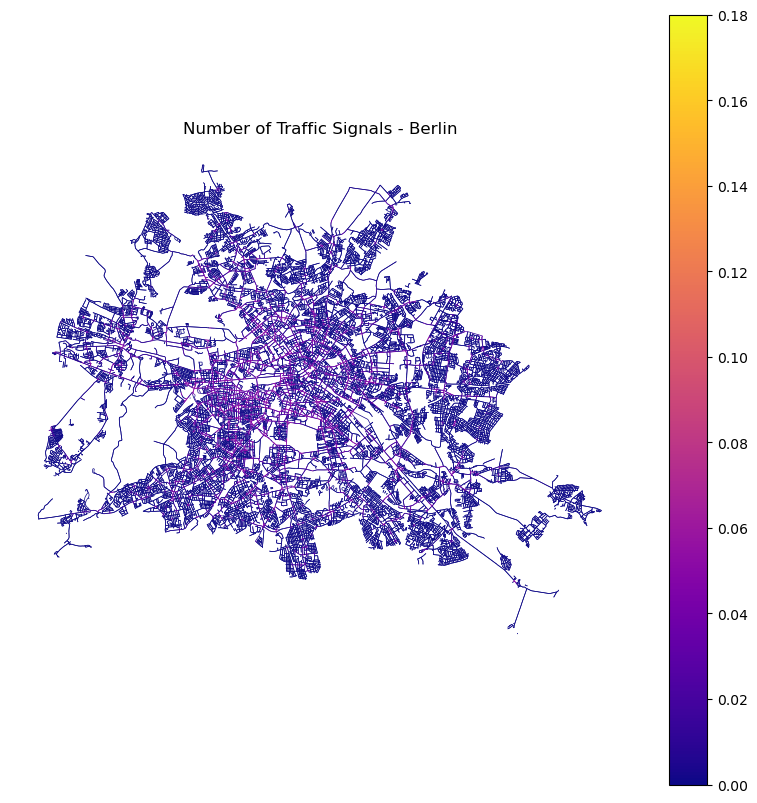

In [38]:
ax = osm_roads_sig.plot(column='signal_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10), vmax=0.18)
ax.set_title('Number of Traffic Signals - Berlin')
ax.set_axis_off()

## Transport in 50 m buffer

In [39]:
transport_join = gpd.sjoin(transport, buffered_50, how="left", predicate="within")
transport_count = transport_join.groupby('index_right').size().rename('transport_count')

traffic_join = gpd.sjoin(pois_traffic, buffered_50, how="left", predicate="within")
traffic_count = traffic_join.groupby('index_right').size().rename('traffic_count')

In [40]:
osm_roads_transport = osm_roads.join(transport_count)
osm_roads_transport = osm_roads_transport.join(traffic_count)
osm_roads_transport['transport_count'] = (
    osm_roads_transport['transport_count'].fillna(0) +
    osm_roads_transport['traffic_count'].fillna(0)
) / osm_roads_transport['length']
q90 = osm_roads_transport['transport_count'].quantile(0.90)
osm_roads_transport['transport_count'] = osm_roads_transport['transport_count'].clip(upper=q90)

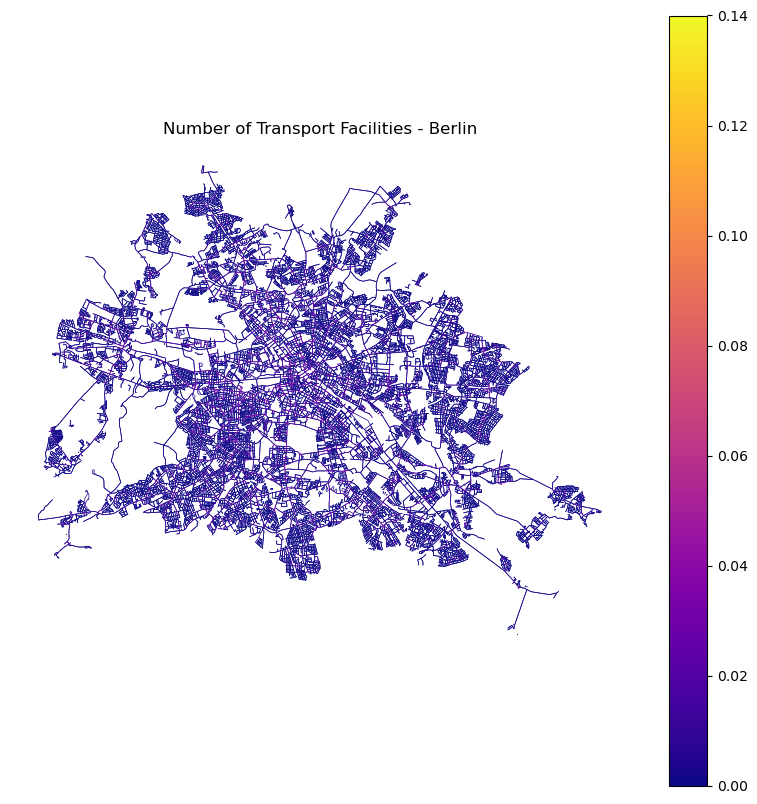

In [41]:
ax = osm_roads_transport.plot(column='transport_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10), vmax=0.14)
ax.set_title('Number of Transport Facilities - Berlin')
ax.set_axis_off()

## POIs noisy in 50 m buffer

In [42]:
pois_join = gpd.sjoin(pois_filtered, buffered_50, how="left", predicate="within")
pois_count = pois_join.groupby('index_right').size().rename('pois_count')
pois_count

index_right
0.0        1
5.0        1
6.0        1
14.0       1
15.0       3
          ..
70877.0    1
70878.0    1
70879.0    5
70880.0    1
70881.0    2
Name: pois_count, Length: 19102, dtype: int64

In [43]:
osm_roads_pois = osm_roads.join(pois_count)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].fillna(0) / osm_roads_pois['length']
q99 = osm_roads_pois['pois_count'].quantile(0.99)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].clip(upper=q99)

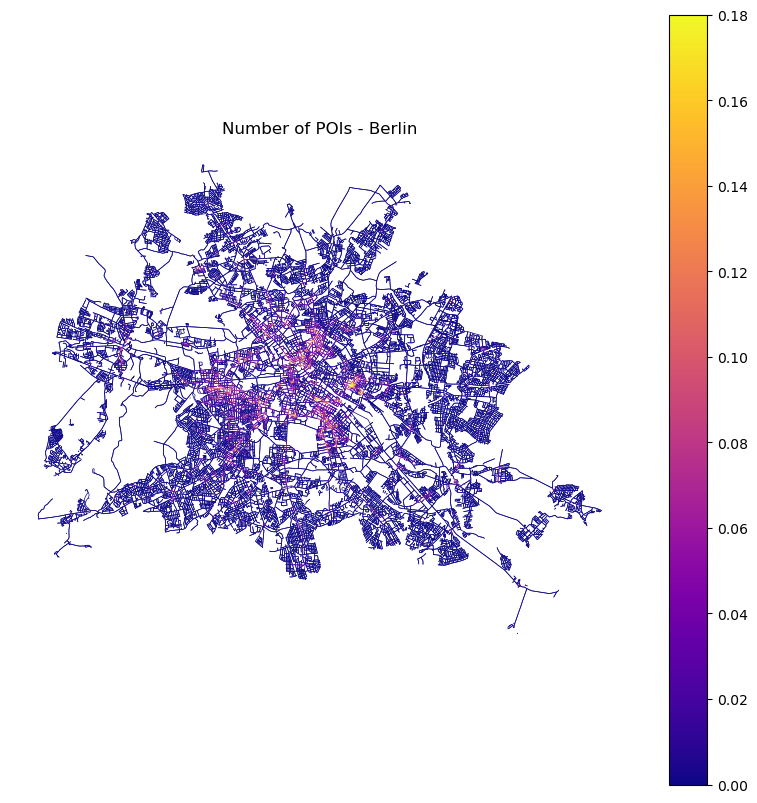

In [44]:
ax = osm_roads_pois.plot(column='pois_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10), vmax=0.18)
ax.set_title('Number of POIs - Berlin')
ax.set_axis_off()

## Create Dataset

In [45]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "signals": osm_roads_sig["signal_count"],
    "transport": osm_roads_transport["transport_count"],
    "pois": osm_roads_pois["pois_count"],
}).fillna(0)
dataset.head()

,road_id,signals,transport,pois
0.0,172539_172562_0,0.027463,0.009154,0.002289
1.0,172539_34694336_0,0.007274,0.002910,0.000000
2.0,172539_34694265_0,0.020748,0.008299,0.000000
3.0,172545_271370539_0,0.050295,0.026704,0.000000
4.0,172545_34694336_0,0.050295,0.019385,0.000000


## Export CSV

In [46]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

path = os.path.join(output_dir, "osm_points_features.csv")
dataset.to_csv(path, index=False)
print(f"Exported: {path}")

Exported: data\osm_points_features.csv
